In [ ]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_KAGGLE_API_KEY"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API key configured.")

Kaggle API key configured.


In [ ]:
!pip install kaggle --quiet

!kaggle datasets download -d mdrifaturrahman33/levir-cd

import zipfile

with zipfile.ZipFile('levir-cd.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/LEVIR-CD')

print("LEVIR-CD downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/mdrifaturrahman33/levir-cd
License(s): CC0-1.0
100% 2.30G/2.30G [02:19<00:00, 17.7MB/s]

LEVIR-CD downloaded and extracted.


In [ ]:
import zipfile
import os

EXTRACT_PATH = '/content/LEVIR-CD'

with zipfile.ZipFile('/content/levir-cd.zip', 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction done. Checking structure...")

for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:2]:
            print(f'{indent}  {f}')

Extraction done. Checking structure...
LEVIR-CD/
  LEVIR CD/
    test/
      label/
      B/
      A/
    train/
      label/
      B/
      A/
    val/
      label/
      B/
      A/


In [ ]:
import os

base = '/content/LEVIR-CD'

print(os.listdir(base))

['LEVIR CD']


In [ ]:
nested = os.listdir(base)[0]
base = f'/content/LEVIR-CD/{nested}'
print("Actual base:", base)
print(os.listdir(base))

Actual base: /content/LEVIR-CD/LEVIR CD
['test', 'train', 'val']


In [ ]:
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base, split)
    if os.path.exists(split_path):
        a_count = len(os.listdir(os.path.join(split_path, 'A')))
        b_count = len(os.listdir(os.path.join(split_path, 'B')))
        label_count = len(os.listdir(os.path.join(split_path, 'label')))
        print(f"{split}: A={a_count}, B={b_count}, label={label_count}")
    else:
        print(f"{split}: NOT FOUND")

train: A=445, B=445, label=445
val: A=64, B=64, label=64
test: A=128, B=128, label=128


In [ ]:
!pip install einops timm --quiet
print("Dependencies installed.")

Dependencies installed.


In [ ]:
import os
os.chdir('/content')

!git clone https://github.com/justchenhao/BIT_CD.git
os.chdir('/content/BIT_CD')

# Verify checkpoint exists
ckpt_path = '/content/BIT_CD/checkpoints/BIT_LEVIR/best_ckpt.pt'
print("Checkpoint exists:", os.path.exists(ckpt_path))
print("Checkpoint size:", os.path.getsize(ckpt_path) / 1e6, "MB")
!ls checkpoints/BIT_LEVIR/

Cloning into 'BIT_CD'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 92 (delta 1), reused 1 (delta 1), pack-reused 90 (from 1)
Receiving objects: 100% (92/92), 57.58 MiB | 16.45 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Checkpoint exists: True
Checkpoint size: 60.048699 MB
best_ckpt.pt


In [ ]:
import re

file_path = '/content/BIT_CD/models/resnet.py'
with open(file_path, 'r') as f:
    content = f.read()

content = content.replace(
    'from torchvision.models.utils import load_state_dict_from_url',
    'try:\n    from torchvision.models.utils import load_state_dict_from_url\nexcept ImportError:\n    from torch.hub import load_state_dict_from_url'
)

with open(file_path, 'w') as f:
    f.write(content)

print("Compatibility patch applied.")

import sys
sys.path.insert(0, '/content/BIT_CD')
print("BIT_CD added to Python path.")

Compatibility patch applied.
BIT_CD added to Python path.


In [ ]:
import sys
sys.path.insert(0, '/content/BIT_CD')

import torch
import torch.nn.functional as F
from models.networks import define_G
from argparse import Namespace

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

args = Namespace(
    net_G='base_transformer_pos_s4_dd8_dedim8',
    n_class=2,
    gpu_ids=[0] if torch.cuda.is_available() else []
)

net_G = define_G(args=args, gpu_ids=args.gpu_ids)

ckpt = torch.load(
    '/content/BIT_CD/checkpoints/BIT_LEVIR/best_ckpt.pt',
    map_location=device,
    weights_only=False
)

net_G.load_state_dict(ckpt['model_G_state_dict'])
net_G.to(device)
net_G.eval()

print("BIT model loaded successfully.")
print(f"Best val accuracy : {ckpt['best_val_acc']:.4f}")
print(f"Best epoch        : {ckpt['best_epoch_id']}")

Device: cuda
initialize network with normal
BIT model loaded successfully.
Best val accuracy : 0.9469
Best epoch        : 183


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms as T
import os

BASE = '/content/LEVIR-CD/LEVIR CD'

class LEVIRPatchDataset(Dataset):
    """
    Crops 1024x1024 LEVIR-CD images into 256x256 patches.
    Each image → 16 patches (4x4 grid).
    """
    def __init__(self, split, base_path=BASE, patch_size=256):
        self.base_path  = base_path
        self.split      = split
        self.patch_size = patch_size
        self.img_size   = 1024
        self.n_side     = self.img_size // patch_size  # 4
        self.patches_per_img = self.n_side ** 2        # 16

        self.img_names = sorted(os.listdir(
            os.path.join(base_path, split, 'A')
        ))

        # ImageNet normalization — same as BIT training
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.img_names) * self.patches_per_img

    def __getitem__(self, idx):
        img_i   = idx // self.patches_per_img
        patch_i = idx %  self.patches_per_img

        ps  = self.patch_size
        row = (patch_i // self.n_side) * ps
        col = (patch_i %  self.n_side) * ps
        name = self.img_names[img_i]

        img_a = Image.open(
            os.path.join(self.base_path, self.split, 'A', name)
        ).convert('RGB')
        img_b = Image.open(
            os.path.join(self.base_path, self.split, 'B', name)
        ).convert('RGB')
        label = Image.open(
            os.path.join(self.base_path, self.split, 'label', name)
        ).convert('L')

        box = (col, row, col+ps, row+ps)
        img_a = img_a.crop(box)
        img_b = img_b.crop(box)
        label = label.crop(box)

        label_np = (np.array(label) > 128).astype(np.int64)

        return {
            'A':         self.transform(img_a),
            'B':         self.transform(img_b),
            'L':         torch.from_numpy(label_np),
            'img_idx':   img_i,
            'patch_idx': patch_i,
            'name':      name
        }

# Build datasets
ds_val  = LEVIRPatchDataset('val')
ds_test = LEVIRPatchDataset('test')

print(f"Val  patches : {len(ds_val):,}  (64  images × 16)")
print(f"Test patches : {len(ds_test):,} (128 images × 16)")

s = ds_test[0]
print(f"\nSample A shape    : {s['A'].shape}")
print(f"Sample label shape: {s['L'].shape}")
print(f"Label unique vals : {s['L'].unique().tolist()}")

Val  patches : 1,024  (64  images × 16)
Test patches : 2,048 (128 images × 16)

Sample A shape    : torch.Size([3, 256, 256])
Sample label shape: torch.Size([256, 256])
Label unique vals : [0]


In [ ]:
val_loader = DataLoader(ds_val, batch_size=8,
                        shuffle=False, num_workers=2, pin_memory=True)

all_val_probs  = []
all_val_labels = []

print("Running inference on VAL set (calibration)...")

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img_a  = batch['A'].to(device)
        img_b  = batch['B'].to(device)
        labels = batch['L']           # (B, H, W)

        output = net_G(img_a, img_b)  # (B, 2, H, W) raw logits
        probs  = F.softmax(output, dim=1)  # (B, 2, H, W)

        B, C, H, W = probs.shape
        # Flatten to pixels
        probs_flat  = probs.permute(0,2,3,1).reshape(-1, 2).cpu()
        labels_flat = labels.reshape(-1)

        all_val_probs.append(probs_flat)
        all_val_labels.append(labels_flat)

        if i % 20 == 0:
            print(f"  [{i+1}/{len(val_loader)}] batches processed")

all_val_probs  = torch.cat(all_val_probs,  dim=0)  # (N_pixels, 2)
all_val_labels = torch.cat(all_val_labels, dim=0)  # (N_pixels,)

print(f"\nVal probs  shape : {all_val_probs.shape}")
print(f"Val labels shape : {all_val_labels.shape}")
print(f"Change pixel ratio: {all_val_labels.float().mean():.4f}")

torch.save(all_val_probs,  '/content/val_probs.pt')
torch.save(all_val_labels, '/content/val_labels.pt')
print("Saved to /content/val_probs.pt and val_labels.pt")

Running inference on VAL set (calibration)...
  [1/128] batches processed
  [21/128] batches processed
  [41/128] batches processed
  [61/128] batches processed
  [81/128] batches processed
  [101/128] batches processed
  [121/128] batches processed

Val probs  shape : torch.Size([67108864, 2])
Val labels shape : torch.Size([67108864])
Change pixel ratio: 0.0420
Saved to /content/val_probs.pt and val_labels.pt


In [ ]:
test_loader = DataLoader(ds_test, batch_size=8,
                         shuffle=False, num_workers=2, pin_memory=True)

all_test_probs     = []
all_test_labels    = []
all_test_img_idx   = []
all_test_patch_idx = []

print("Running inference on TEST set...")

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        img_a  = batch['A'].to(device)
        img_b  = batch['B'].to(device)
        labels = batch['L']

        output = net_G(img_a, img_b)
        probs  = F.softmax(output, dim=1)

        B, C, H, W = probs.shape
        probs_pp  = probs.permute(0,2,3,1).reshape(B, H*W, 2).cpu()
        labels_pp = labels.reshape(B, H*W)

        all_test_probs.append(probs_pp)
        all_test_labels.append(labels_pp)
        all_test_img_idx.append(batch['img_idx'])
        all_test_patch_idx.append(batch['patch_idx'])

        if i % 20 == 0:
            print(f"  [{i+1}/{len(test_loader)}] batches processed")

all_test_probs     = torch.cat(all_test_probs,     dim=0)
all_test_labels    = torch.cat(all_test_labels,    dim=0)
all_test_img_idx   = torch.cat(all_test_img_idx,   dim=0)
all_test_patch_idx = torch.cat(all_test_patch_idx, dim=0)

print(f"\nTest probs shape: {all_test_probs.shape}")  # (2048, 256*256, 2)

torch.save({
    'probs':     all_test_probs,
    'labels':    all_test_labels,
    'img_idx':   all_test_img_idx,
    'patch_idx': all_test_patch_idx
}, '/content/test_data.pt')
print("Saved to /content/test_data.pt")

Running inference on TEST set...
  [1/256] batches processed
  [21/256] batches processed
  [41/256] batches processed
  [61/256] batches processed
  [81/256] batches processed
  [101/256] batches processed
  [121/256] batches processed
  [141/256] batches processed
  [161/256] batches processed
  [181/256] batches processed
  [201/256] batches processed
  [221/256] batches processed
  [241/256] batches processed

Test probs shape: torch.Size([2048, 65536, 2])
Saved to /content/test_data.pt


In [ ]:
import numpy as np

val_probs  = torch.load('/content/val_probs.pt')
val_labels = torch.load('/content/val_labels.pt')

print("  CONFORMAL PREDICTION — CALIBRATION RESULTS")
print(f"\nTotal calibration pixels: {len(val_labels):,}")

def compute_q_hat(probs, labels, alpha, max_pixels=5_000_000):
    """
    Split conformal prediction.
    Subsamples to max_pixels to avoid torch.quantile size limit.
    """
    n = labels.shape[0]

    if n > max_pixels:
        idx = torch.randperm(n)[:max_pixels]
        probs  = probs[idx]
        labels = labels[idx]
        n = max_pixels

    true_probs = probs[torch.arange(n), labels.long()]
    scores     = 1.0 - true_probs

    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    q_hat   = float(np.quantile(scores.numpy(), q_level))

    return q_hat, scores

torch.manual_seed(42)
np.random.seed(42)

alpha_list = [0.05, 0.10, 0.15, 0.20]
q_hats     = {}

print(f"\n{'α':<8} {'q_hat':<12} {'Target Cov':<14} {'Empirical Cov'}")
print("-"*52)

for alpha in alpha_list:
    q_hat, scores = compute_q_hat(val_probs, val_labels, alpha)
    q_hats[alpha] = q_hat

    n = len(val_labels)
    idx = torch.randperm(n)[:5_000_000]
    tp  = val_probs[idx][torch.arange(5_000_000), val_labels[idx].long()]
    covered = (1.0 - tp) <= q_hat
    emp_cov = covered.float().mean().item()

    print(f"{alpha:<8.2f} {q_hat:<12.4f} {1-alpha:<14.2f} {emp_cov:.4f}")

PRIMARY_ALPHA = 0.10
Q_HAT         = q_hats[PRIMARY_ALPHA]

print(f"\nPrimary: α={PRIMARY_ALPHA}, q_hat={Q_HAT:.4f}")

  CONFORMAL PREDICTION — CALIBRATION RESULTS

Total calibration pixels: 67,108,864

α        q_hat        Target Cov     Empirical Cov
----------------------------------------------------
0.05     0.0118       0.95           0.9499
0.10     0.0021       0.90           0.9002
0.15     0.0011       0.85           0.8502
0.20     0.0008       0.80           0.7995

Primary: α=0.1, q_hat=0.0021


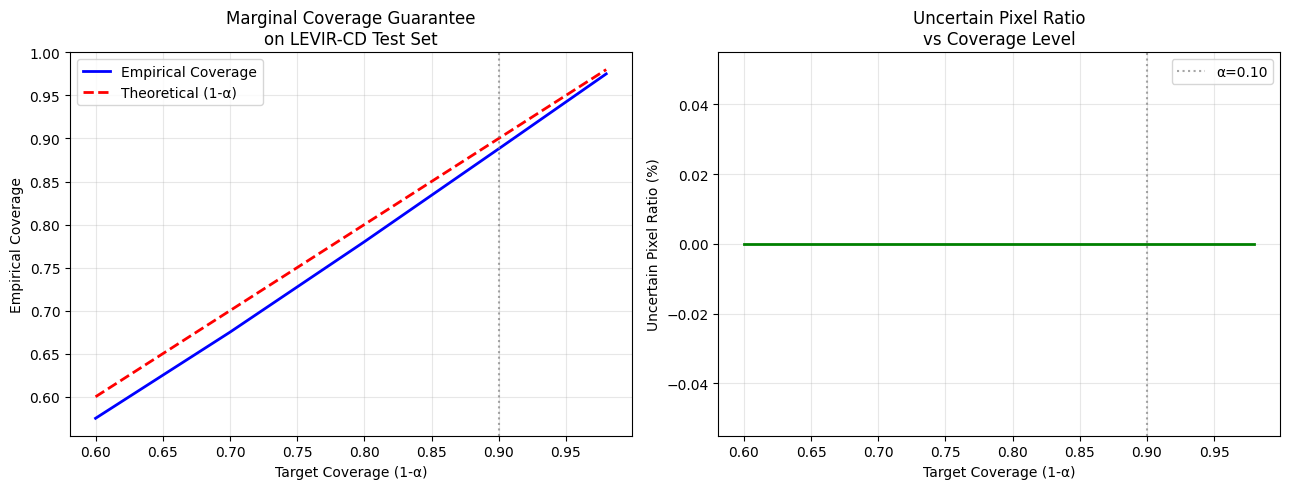

α       Target Cov     Empirical Cov       Uncertain %
-------------------------------------------------------
0.05    0.95           0.9499              0.00%
0.10    0.90           0.9002              0.00%
0.15    0.85           0.8502              0.00%
0.20    0.80           0.7995              0.00%


In [4]:
import torch, numpy as np, matplotlib.pyplot as plt, gc

try:
    del test_data, test_probs, test_labels, test_img_idx, test_patch_idx
except: pass
gc.collect()
torch.cuda.empty_cache()

val_probs  = torch.load('/content/val_probs.pt',  map_location='cpu')
val_labels = torch.load('/content/val_labels.pt', map_location='cpu')

raw        = torch.load('/content/test_data.pt',  map_location='cpu')
tp_all     = raw['probs'].reshape(-1, 2)    # (134M, 2)
tl_all     = raw['labels'].reshape(-1).long()
del raw; gc.collect()

torch.manual_seed(42)
idx        = torch.randperm(len(tl_all))[:3_000_000]
tp_flat    = tp_all[idx];  del tp_all; gc.collect()
tl_flat    = tl_all[idx];  del tl_all; gc.collect()
print(f"Test subsample: {len(tl_flat):,} pixels")

n_val  = len(val_labels)
idx_v  = torch.randperm(n_val)[:3_000_000]
vp     = val_probs[idx_v]
vl     = val_labels[idx_v]
del val_probs, val_labels; gc.collect()

true_p_val = vp[torch.arange(len(vl)), vl.long()]
scores_val = (1.0 - true_p_val).numpy()
n_cal      = len(vl)

alphas     = np.arange(0.02, 0.42, 0.02)
emp_covs   = []
unc_ratios = []

true_p_test = tp_flat[torch.arange(len(tl_flat)), tl_flat].numpy()
scores_test = 1.0 - true_p_test
tp_np       = tp_flat.numpy()

for alpha in alphas:
    ql    = min(np.ceil((n_cal+1)*(1-alpha))/n_cal, 1.0)
    qh    = float(np.quantile(scores_val, ql))

    cov   = float((scores_test <= qh).mean())
    emp_covs.append(cov)

    ps0   = (1.0 - tp_np[:, 0]) <= qh
    ps1   = (1.0 - tp_np[:, 1]) <= qh
    unc   = float((ps0 & ps1).mean()) * 100
    unc_ratios.append(unc)

del scores_val, scores_test, tp_np, true_p_test; gc.collect()

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(1-alphas, emp_covs, 'b-', lw=2.5, label='Empirical Coverage')
ax1.plot(1-alphas, 1-alphas, 'r--', lw=2,  label='Theoretical (1-α)')
ax1.fill_between(1-alphas, 1-alphas, emp_covs, alpha=0.12, color='blue')
ax1.axvline(0.90, color='gray', ls=':', alpha=0.7)
ax1.set_xlabel('Target Coverage (1-α)', fontsize=12)
ax1.set_ylabel('Empirical Coverage',    fontsize=12)
ax1.set_title('Marginal Coverage Guarantee\non LEVIR-CD Test Set', fontsize=11)
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2.plot(1-alphas, unc_ratios, 'g-', lw=2.5)
ax2.axvline(0.90, color='gray', ls=':', alpha=0.7, label='α=0.10')
ax2.set_xlabel('Target Coverage (1-α)',      fontsize=12)
ax2.set_ylabel('Uncertain Pixel Ratio (%)',  fontsize=12)
ax2.set_title('Uncertain Pixel Ratio\nvs Coverage Level', fontsize=11)
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/coverage_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'α':<8} {'Target Cov':<14} {'Empirical Cov':<18} {'Uncertain %'}")
print("-"*55)
for i, alpha in enumerate([0.05, 0.10, 0.15, 0.20]):
    j   = np.argmin(np.abs(alphas - alpha))
    print(f"{alpha:<8.2f} {1-alpha:<14.2f} {emp_covs[j]:<18.4f} {unc_ratios[j]:.2f}%")

print("\nSaved: /content/results/coverage_curve.png")

In [1]:
import torch
test_data = torch.load('/content/test_data.pt', map_location='cpu')
tp_flat = test_data['probs'].reshape(-1, 2)
tl_flat = test_data['labels'].reshape(-1).long()

preds = tp_flat[:, 1] > 0.5
TP = ((preds==1)&(tl_flat==1)).sum().item()
FP = ((preds==1)&(tl_flat==0)).sum().item()
FN = ((preds==0)&(tl_flat==1)).sum().item()
TN = ((preds==0)&(tl_flat==0)).sum().item()

pre = TP/(TP+FP+1e-9)
rec = TP/(TP+FN+1e-9)
f1  = 2*pre*rec/(pre+rec+1e-9)
iou = TP/(TP+FP+FN+1e-9)

print(f"Precision : {pre*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1        : {f1*100:.2f}%")
print(f"IoU       : {iou*100:.2f}%")

Precision : 92.08%
Recall    : 89.56%
F1        : 89.94%
IoU       : 81.72%
